# B-90001A — AutoML

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from clearml import Task

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from transpetro_modelos.config import EQUIPMENT_CONFIGS
from transpetro_modelos.data.loading import load_equipment_data
from transpetro_modelos.data.preprocessing import run_preprocessing


In [6]:
# ==============================
# Configuracao
# ==============================
TASK_ID = '54a465f17f304f3f8947dcbeb27bfdd4'  # obrigatorio
EQUIPMENT_ID = 'B-90001A_interpolated'
USE_FULL_SCORES = True

# Eventos
EVENT_DATE_F1 = '2021-08-28'
EVENT_LABEL_F1 = 'Inicio restricao (28/Out/2021)'
EVENT_TS_F1 = pd.Timestamp(EVENT_DATE_F1)

# Sensibilidade
AUTO_USE_CALIBRATED_SENSITIVITY = True
SENSITIVITY_PRESET = 'conservative'  # 'conservative' | 'balanced' | 'sensitive' | 'custom'
CALIB_START = '2020-12-01'
CALIB_END = '2021-08-18'
CALIB_PERCENTILES = [95, 97, 98, 99, 99.5, 99.7, 99.9]
CALIB_PERSISTENCE_GRID = [(1, 1), (2, 3), (3, 5), (4, 6)]
TARGET_ALERTS_PER_DAY = 2.0

# Visualizacao
PLOT_MODE = 'separated'  # 'separated' | 'consolidated'
ANOMALY_HIGHLIGHT_STYLE = 'lollipop'  # 'lollipop' | 'big_points'
SAVE_PLOTS = False
OUTPUT_DPI = 180
FIGSIZE_WIDTH = 12
PANEL_HEIGHT = 2.5

In [7]:
def _normalize_scores_df(scores):
    if not isinstance(scores, pd.DataFrame):
        raise TypeError(f'artifact de scores deve ser DataFrame, veio: {type(scores)}')

    required_cols = {'reconstruction_error', 'is_anomaly'}
    missing = required_cols - set(scores.columns)
    if missing:
        raise ValueError(f'colunas faltando em scores: {missing}')

    s = scores.copy()
    s.index = pd.to_datetime(s.index)
    s = s.sort_index()
    s['is_anomaly'] = s['is_anomaly'].astype(bool)
    return s[['reconstruction_error', 'is_anomaly']]


def load_automl_outputs(task_id: str):
    task = Task.get_task(task_id=task_id)
    available = set(task.artifacts.keys())
    print(f"Artifacts disponíveis: {sorted(available)}")

    # Ranking completo
    ranking = None
    if "automl_results" in available:
        ranking = task.artifacts["automl_results"].get()

    # Melhor trial
    best_trial_info = None
    if "best_trial" in available:
        best_trial_info = task.artifacts["best_trial"].get()

    # Scores obrigatórios
    if "best_full_scores" not in available:
        raise KeyError("Artifact 'best_full_scores' não encontrado na task AutoML.")
    scores = _normalize_scores_df(task.artifacts["best_full_scores"].get())

    # Threshold: tenta best_trial primeiro, fallback no ranking
    threshold = None
    if best_trial_info is not None:
        results = best_trial_info.get("results", {})
        raw = results.get("threshold")
        if raw is not None:
            threshold = float(raw)

    if threshold is None and ranking is not None and len(ranking) > 0:
        threshold = float(ranking.iloc[0]["threshold"])
        print("[AVISO] best_trial sem threshold — extraído do ranking (melhor trial).")

    if threshold is None:
        raise ValueError("Não foi possível determinar o threshold do melhor trial.")

    return task, ranking, best_trial_info, scores, threshold

def load_plot_base(equipment_id: str):
    config = EQUIPMENT_CONFIGS[equipment_id]
    df_raw = load_equipment_data(equipment_id, from_clearml=False)

    # Pre-split para alinhar timestamps da serie de sensores ao score
    pre_steps = config.pre_split_steps

    if pre_steps:
        df_base, _, _ = run_preprocessing(df_raw, pre_steps, fitted_scaler=None)
    else:
        df_base = df_raw

    df_base = df_base.sort_index()
    df_base.index = pd.to_datetime(df_base.index)
    return df_base, config

def slice_window(df_base, scores, window_start, window_end):
    start_ts = pd.Timestamp(window_start)
    end_ts = pd.Timestamp(window_end)

    dfw = df_base.loc[start_ts:end_ts].copy()
    sw = scores.loc[start_ts:end_ts].copy()

    common_idx = dfw.index.intersection(sw.index)
    if len(common_idx) == 0:
        raise ValueError(f'nao ha intersecao de timestamps na janela {window_start}..{window_end}')

    return dfw.loc[common_idx], sw.loc[common_idx]


def print_preprocessing_confirmation(config):
    print('Preprocessamento aplicado para score/predict:')
    print('  1) Pre-split (base bruta):')
    for step in config.pre_split_steps:
        print(f'     - {step}')

    print('  2) Pos-split/predict (modelo): clip + normalize(robust),')
    print('     usando clip_bounds e scaler ajustados no treino (conforme train_equipment.py).')


def persistence_filter(flags: pd.Series, k: int, n: int) -> pd.Series:
    if k == 1 and n == 1:
        return flags.astype(bool)
    roll = flags.astype(int).rolling(window=n, min_periods=n).sum()
    return (roll >= k).fillna(False).astype(bool)


def recommend_sensitivity(scores: pd.DataFrame, calib_start: str, calib_end: str):
    calib = scores.loc[pd.Timestamp(calib_start):pd.Timestamp(calib_end)].copy()
    if calib.empty:
        raise ValueError(f'janela de calibracao vazia: {calib_start}..{calib_end}')

    rows = []
    for p in CALIB_PERCENTILES:
        thr = float(np.percentile(calib['reconstruction_error'].values, p))
        for (k, n) in CALIB_PERSISTENCE_GRID:
            flags = persistence_filter(scores['reconstruction_error'] > thr, k=k, n=n)
            n_days = max((scores.index.max().normalize() - scores.index.min().normalize()).days + 1, 1)
            alerts_per_day = float(flags.sum()) / float(n_days)
            rows.append({
                'percentile': float(p),
                'threshold': float(thr),
                'k': int(k),
                'n': int(n),
                'alerts_per_day': alerts_per_day,
                'distance_to_target': abs(alerts_per_day - TARGET_ALERTS_PER_DAY),
            })

    calib_df = pd.DataFrame(rows).sort_values(['distance_to_target', 'alerts_per_day']).reset_index(drop=True)
    best = calib_df.iloc[0]
    return {
        'threshold': float(best['threshold']),
        'k': int(best['k']),
        'n': int(best['n']),
        'percentile': float(best['percentile']),
        'alerts_per_day': float(best['alerts_per_day']),
        'table': calib_df,
    }


In [8]:
def plot_anomaly_panels(
    df_window, scores_window, threshold_flags, anomaly_flags,
    threshold, threshold_label, n_anomalies,
    event_date, event_label, title,
    output_path=None, dpi=180,
    plot_mode='separated', save_plots=False,
    anomaly_highlight_style='lollipop',
):
    plt.style.use('seaborn-v0_8-whitegrid')
    mode = str(plot_mode).strip().lower()
    highlight_style = str(anomaly_highlight_style).strip().lower()
    saved_paths = []
    sensors = list(df_window.columns)
    anomaly_idx = scores_window.index[anomaly_flags]

    def maybe_save(fig, suffix=None):
        if not save_plots or output_path is None:
            return None
        output_path.parent.mkdir(parents=True, exist_ok=True)
        target = output_path.with_name(f"{output_path.stem}_{suffix}{output_path.suffix}") if suffix else output_path
        fig.savefig(target, dpi=dpi, bbox_inches='tight')
        saved_paths.append(target)
        return target

    def _plot_score_ax(ax_s, x, y):
        ax_s.plot(x, y, color='purple', linewidth=0.9, alpha=0.55, label='Score de Anomalia (MSE)')
        ax_s.axhline(threshold, color='red', linestyle='--', linewidth=1.3, label=threshold_label)
        ax_s.fill_between(x, threshold, y, where=(y > threshold), color='red', alpha=0.10)
        idx_thr = scores_window.index[threshold_flags]
        if len(idx_thr) > 0:
            ax_s.scatter(idx_thr, scores_window.loc[idx_thr, 'reconstruction_error'],
                         s=8, color='orange', alpha=0.20, label='Cruzamento bruto', zorder=2)
        idx_pers = scores_window.index[anomaly_flags]
        if len(idx_pers) > 0:
            y_pers = scores_window.loc[idx_pers, 'reconstruction_error']
            if highlight_style == 'lollipop':
                baseline = float(np.nanmin(y)) if len(y) else 0.0
                ax_s.vlines(idx_pers, ymin=baseline, ymax=y_pers.values,
                            color='red', alpha=0.45, linewidth=1.2, zorder=4, label='Persistencia (lollipop)')
                ax_s.scatter(idx_pers, y_pers, s=44, facecolor='red', edgecolor='white',
                             linewidth=0.9, alpha=0.95, label='Alerta com persistencia', zorder=5)
            else:
                ax_s.scatter(idx_pers, y_pers, s=58, facecolor='red', edgecolor='white',
                             linewidth=1.0, alpha=0.95, label='Alerta com persistencia', zorder=5)
        ax_s.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
        ax_s.text(0.99, 0.97, f'Anomalias (persistencia): {int(n_anomalies)}',
                  transform=ax_s.transAxes, ha='right', va='top', fontsize=8,
                  bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='gray'))
        ax_s.set_ylabel('Score de Anomalia', fontsize=9)
        ax_s.set_xlabel('Tempo (Data/Hora)', fontsize=10)
        ax_s.tick_params(axis='both', labelsize=8)
        ax_s.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)

    if mode == 'separated':
        for col in sensors:
            fig, ax = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.4))
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
            ax.set_ylabel(col, fontsize=9)
            ax.set_xlabel('Tempo (Data/Hora)', fontsize=10)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
            fig.suptitle(f'{title} | {col}', fontsize=14, fontweight='bold', y=0.995)
            fig.tight_layout(rect=[0, 0, 1, 0.96])
            slug = ''.join(ch if ch.isalnum() else '_' for ch in str(col)).strip('_').lower()
            maybe_save(fig, suffix=f'sensor_{slug}')
            plt.show()

        fig_s, ax_s = plt.subplots(1, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * 1.6))
        _plot_score_ax(ax_s, scores_window.index, scores_window['reconstruction_error'])
        fig_s.suptitle(f'{title} | Score de Anomalia', fontsize=14, fontweight='bold', y=0.995)
        fig_s.tight_layout(rect=[0, 0, 1, 0.96])
        maybe_save(fig_s, suffix='score')
        plt.show()
    else:
        n_rows = len(sensors) + 1
        fig, axes = plt.subplots(n_rows, 1, figsize=(FIGSIZE_WIDTH, PANEL_HEIGHT * n_rows),
                                  sharex=True, gridspec_kw={'height_ratios': [1] * len(sensors) + [0.95]})
        for i, col in enumerate(sensors):
            ax = axes[i]
            ax.plot(df_window.index, df_window[col], color='steelblue', linewidth=1.0, alpha=0.85, label=f'Serie: {col}')
            anom_vals = df_window[col].reindex(anomaly_idx).dropna()
            if not anom_vals.empty:
                ax.scatter(anom_vals.index, anom_vals.values, s=28, color='red', edgecolor='none', zorder=4, label='Anomalia')
            ax.axvline(event_date, color='orange', linestyle='--', linewidth=1.4, label=event_label)
            ax.set_ylabel(col, fontsize=9)
            ax.tick_params(axis='both', labelsize=8)
            ax.legend(loc='upper left', fontsize=7, ncol=3, frameon=True)
        _plot_score_ax(axes[-1], scores_window.index, scores_window['reconstruction_error'])
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
        fig.tight_layout(rect=[0, 0, 1, 0.99])
        maybe_save(fig)
        plt.show()

    return saved_paths

In [ ]:
task, ranking, best_trial_info, scores, threshold = load_automl_outputs(TASK_ID)

config = EQUIPMENT_CONFIGS[EQUIPMENT_ID]
failure_date = getattr(config, "failure_date", None)

print(f"\nTask: {task.id}")
print(f"Equipamento: {EQUIPMENT_ID}")
print(f"Scores: {len(scores)} amostras ({scores.index.min()} → {scores.index.max()})")
print(f"Threshold: {threshold:.6f}")
print(f"Trials no rank: {len(ranking) if ranking is not None else 'N/A'}")
if failure_date:
    print(f"Failure date: {failure_date}")

Artifacts disponíveis: ['automl_results', 'best_full_scores', 'best_model', 'best_trial', 'preprocessing_artifacts']

Task           : 54a465f17f304f3f8947dcbeb27bfdd4
Equipamento    : B-90001A_interpolated
Scores         : 204015 amostras (2020-12-16 18:04:00 → 2021-08-28 06:29:00)
Threshold      : 0.001378
Trials no rank : 240
Failure date   : 2021-08-28 00:00:00


In [10]:
df_base, config = load_plot_base(EQUIPMENT_ID)

In [11]:
if ranking is None:
    print("Artifact 'automl_results' não disponível.")
else:
    top_cols = [
        "model", "preset", "val_start", "val_end", "threshold_percentile",
        "composite_score", "prefailure_alert_rate", "normal_alert_rate",
        "discrimination_ratio", "val_loss", "threshold",
        "n_anomalies", "scored_samples",
    ]
    cols = [c for c in top_cols if c in ranking.columns]

    fmt = {}
    for c in ("composite_score", "val_loss", "threshold"):
        if c in cols:
            fmt[c] = "{:.5f}"
    for c in ("prefailure_alert_rate", "normal_alert_rate"):
        if c in cols:
            fmt[c] = "{:.2%}"
    if "discrimination_ratio" in cols:
        fmt["discrimination_ratio"] = "{:.2f}"
    if "threshold_percentile" in cols:
        fmt["threshold_percentile"] = "{:.1f}"

    gradient_cols = [c for c in ["composite_score"] if c in cols]

    display(
        ranking[cols]
        .head(20)
        .style
        .format(fmt)
        .background_gradient(subset=gradient_cols, cmap="Greens")
        .set_caption("Top-20 trials — ordenado por composite_score")
    )

,model,preset,val_start,threshold_percentile,composite_score,prefailure_alert_rate,normal_alert_rate,discrimination_ratio,val_loss,threshold,n_anomalies,scored_samples
0,dense,moving_average_interpolated,2021-08-09,90.0,0.75377,80.64%,6.53%,12.35,0.00669,0.00138,27308,204015
1,ocsvm,moving_average_interpolated,2021-08-09,90.0,0.67205,72.32%,7.07%,10.22,0.00000,0.00000,26492,204015
2,ocsvm,moving_average_interpolated,2021-08-09,90.0,0.67205,72.32%,7.07%,10.22,0.00000,0.00000,26492,204015
3,ocsvm,moving_average_interpolated,2021-08-09,90.0,0.65426,70.62%,7.36%,9.60,0.00000,-44.73418,26393,204015
4,ocsvm,moving_average_interpolated,2021-08-09,90.0,0.65426,70.62%,7.36%,9.60,0.00000,-44.73418,26393,204015
5,dense,moving_average_interpolated,2021-08-09,90.0,0.65385,68.98%,5.21%,13.23,0.00384,0.00195,26682,204015
6,ocsvm,moving_average_interpolated,2021-08-09,90.0,0.63777,69.08%,7.67%,9.01,0.00000,-15.30547,26408,204015
7,ocsvm,moving_average_interpolated,2021-08-09,90.0,0.63777,69.08%,7.67%,9.01,0.00000,-15.30551,26408,204015
8,dense,moving_average_interpolated,2021-08-09,90.0,0.62369,67.30%,7.32%,9.19,0.00293,0.00113,26806,204015
9,dense,moving_average_interpolated,2021-08-09,97.5,0.60841,61.63%,1.28%,47.97,0.01082,0.00542,11330,204015


In [12]:
if best_trial_info is not None:
    results = best_trial_info.get("results", {})
    display_keys = [
        "model", "preset", "val_start", "threshold_percentile",
        "composite_score", "prefailure_alert_rate", "normal_alert_rate",
        "discrimination_ratio", "val_loss", "threshold",
        "n_anomalies", "scored_samples", "anomaly_rate",
        "n_prefailure_alerts", "n_prefailure_samples",
        "n_normal_alerts", "n_normal_samples",
        "train_score_mean", "train_score_std",
        "learning_rate", "batch_size", "epochs",
        "seq_len", "lstm_hidden_dim", "lstm_num_layers",
        "ocsvm_nu", "ocsvm_gamma",
        "dense_layers",
    ]
    summary_rows = [
        {"campo": k, "valor": results.get(k, "—")}
        for k in display_keys
        if k in results
    ]
    display(
        pd.DataFrame(summary_rows)
        .set_index("campo")
        .style
        .set_caption("Configuração e métricas do melhor trial")
    )
else:
    print("Artifact 'best_trial' não disponível.")

,valor
campo,
model,dense
preset,moving_average_interpolated
val_start,2021-08-09
threshold_percentile,90.000000
composite_score,0.753766
prefailure_alert_rate,0.806440
normal_alert_rate,0.065317
discrimination_ratio,12.346618
val_loss,0.006686


In [13]:
# Sensibilidade
preset = str(SENSITIVITY_PRESET).strip().lower()
eff_percentiles = list(CALIB_PERCENTILES)
eff_grid = list(CALIB_PERSISTENCE_GRID)
eff_target = float(TARGET_ALERTS_PER_DAY)

if preset == 'conservative':
    eff_percentiles = [99, 99.5, 99.7, 99.9]
    eff_grid = [(3, 5), (4, 6), (5, 8)]
    eff_target = 0.5
elif preset == 'sensitive':
    eff_percentiles = [95, 97, 98, 99]
    eff_grid = [(1, 1), (2, 3), (3, 5)]
    eff_target = 4.0

if AUTO_USE_CALIBRATED_SENSITIVITY:
    CALIB_PERCENTILES = eff_percentiles
    CALIB_PERSISTENCE_GRID = eff_grid
    TARGET_ALERTS_PER_DAY = eff_target
    sens = recommend_sensitivity(scores, CALIB_START, CALIB_END)
    selected_threshold = float(sens['threshold'])
    selected_k = int(sens['k'])
    selected_n = int(sens['n'])
    threshold_label = (
        f"Limite calibrado (thr={selected_threshold:.4f}, "
        f"p={sens['percentile']:.1f}, k={selected_k}, n={selected_n})"
    )
    print(f'Preset: {preset}')
    print(f'Janela calibracao: {CALIB_START} .. {CALIB_END}')
    print(f'threshold={selected_threshold:.6f}  percentile={sens["percentile"]:.1f}  k={selected_k}  n={selected_n}')
    print(f'Alerts/day estimados: {sens["alerts_per_day"]:.3f}')
else:
    selected_threshold = float(threshold)
    selected_k = 1
    selected_n = 1
    threshold_label = f'Limite do modelo (threshold={selected_threshold:.4f})'
    print('Usando threshold original do modelo.')

Preset: conservative
Janela calibracao: 2020-12-01 .. 2021-08-18
threshold=0.025053  percentile=99.9  k=4  n=6
Alerts/day estimados: 0.648


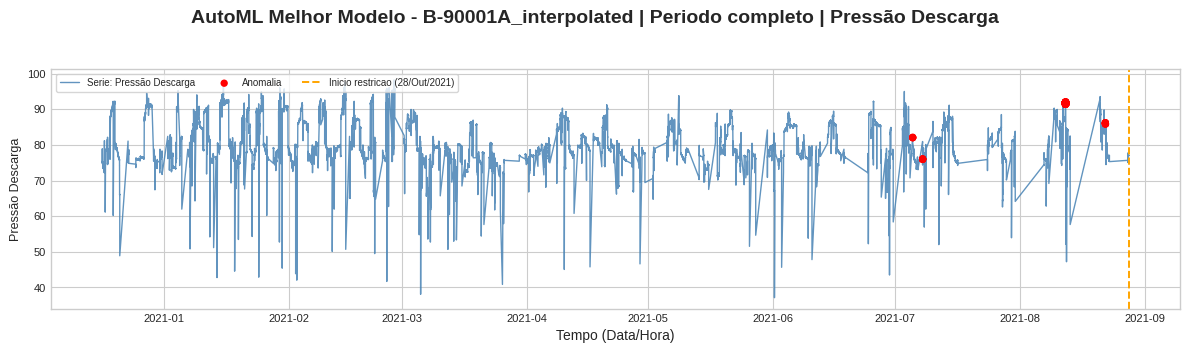

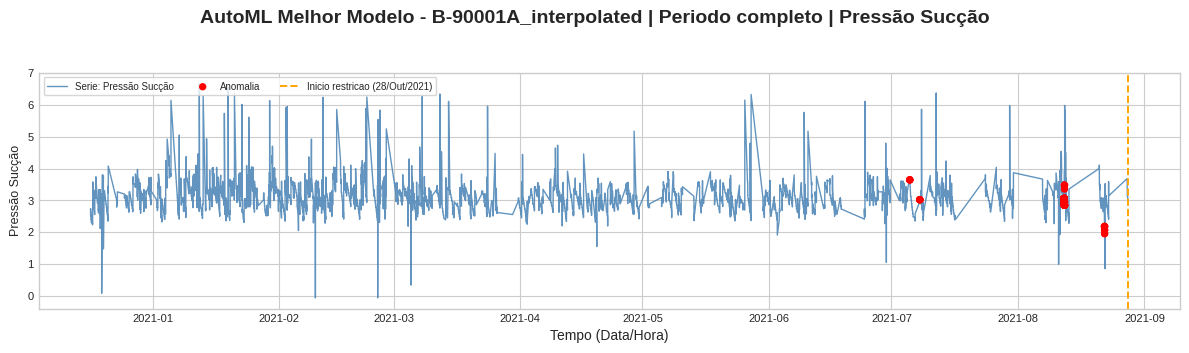

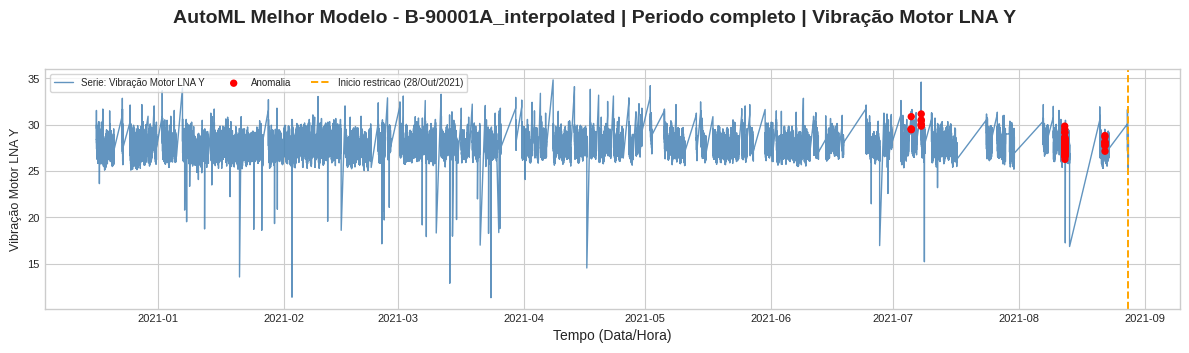

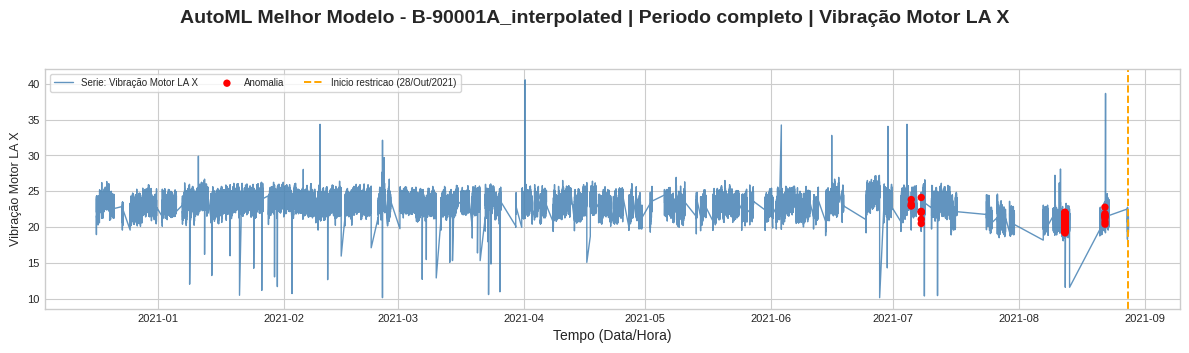

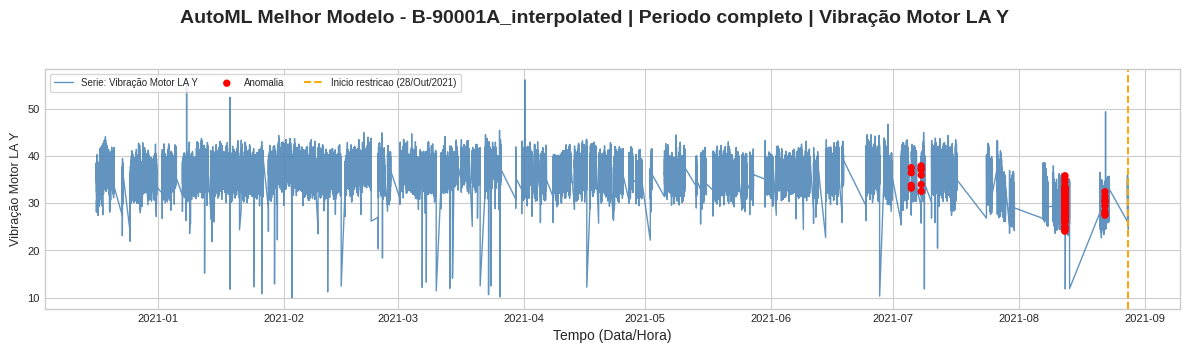

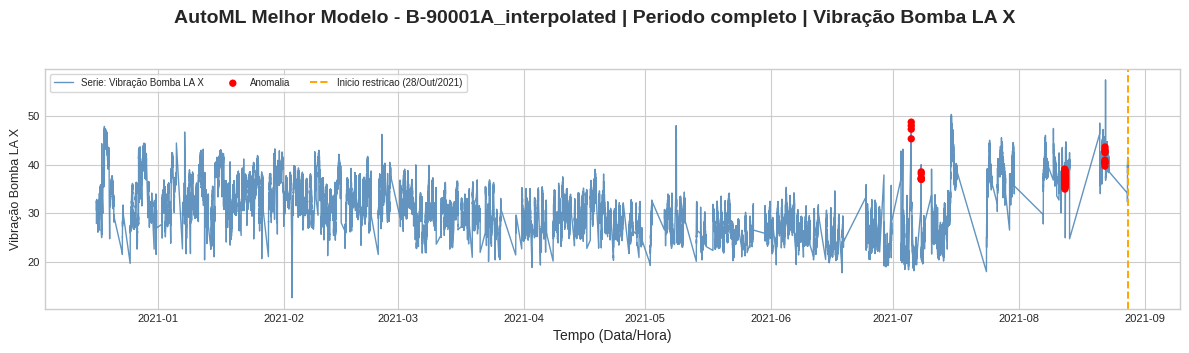

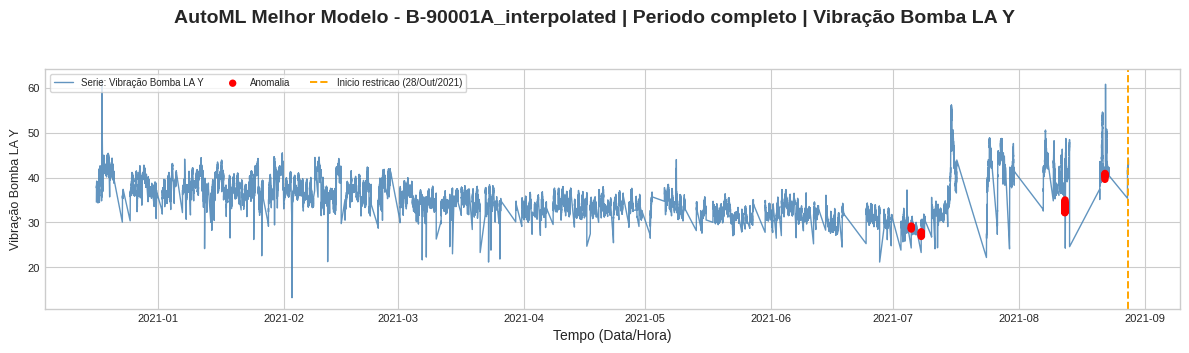

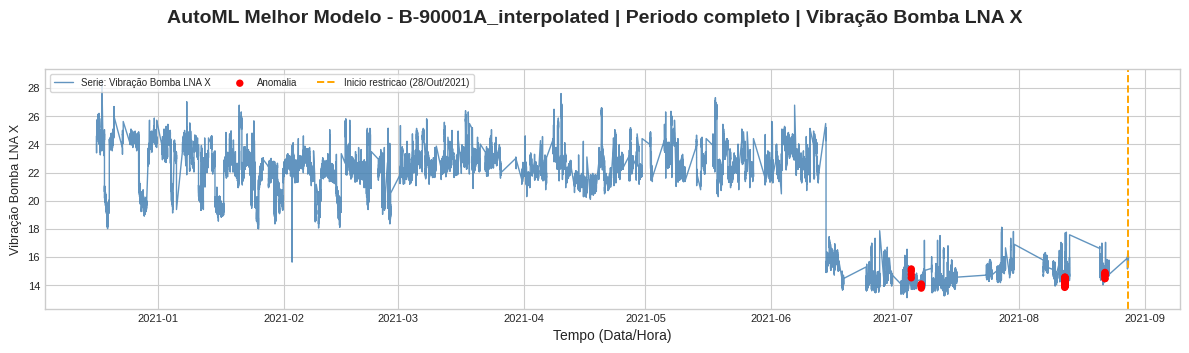

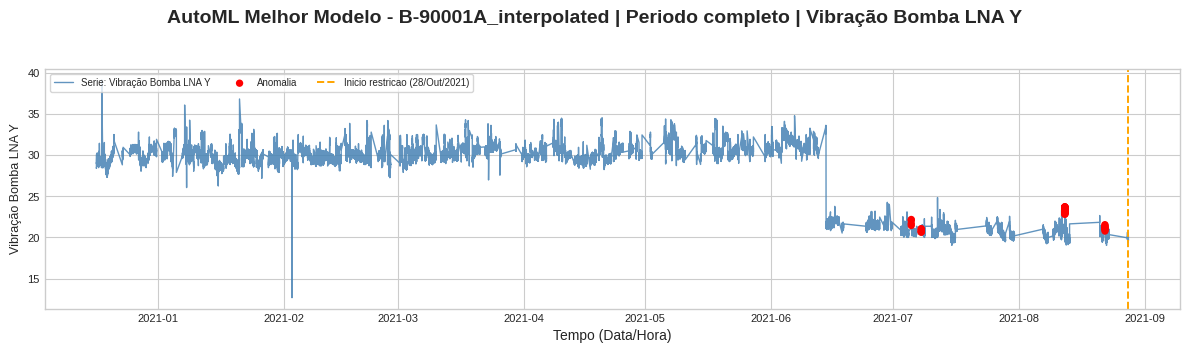

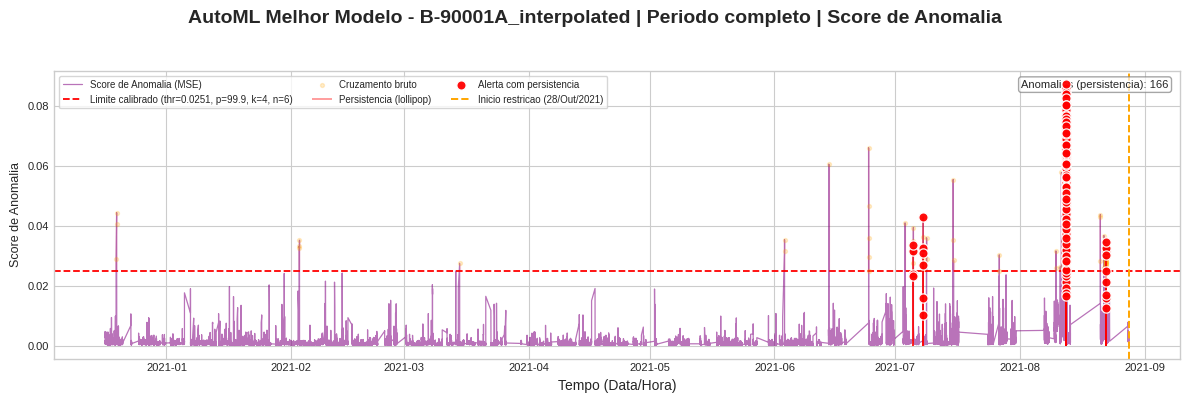

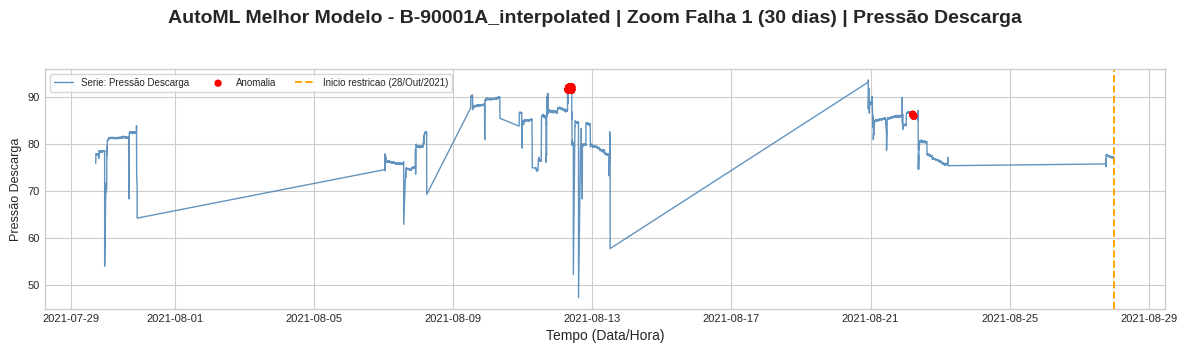

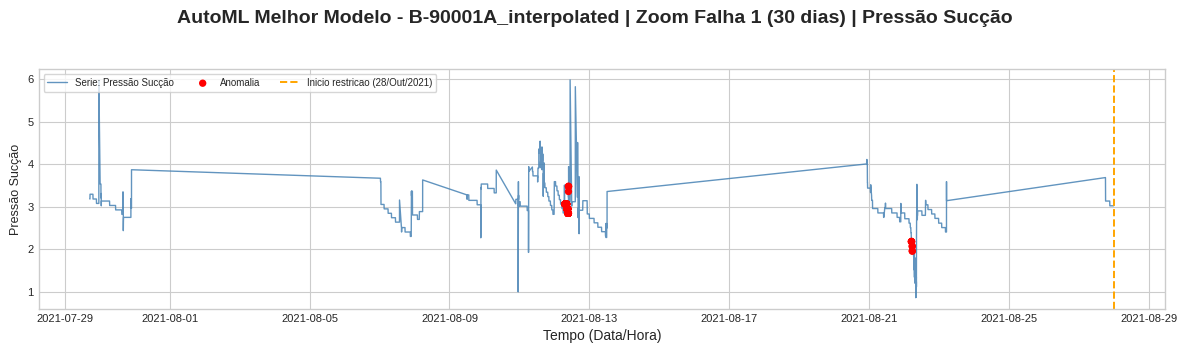

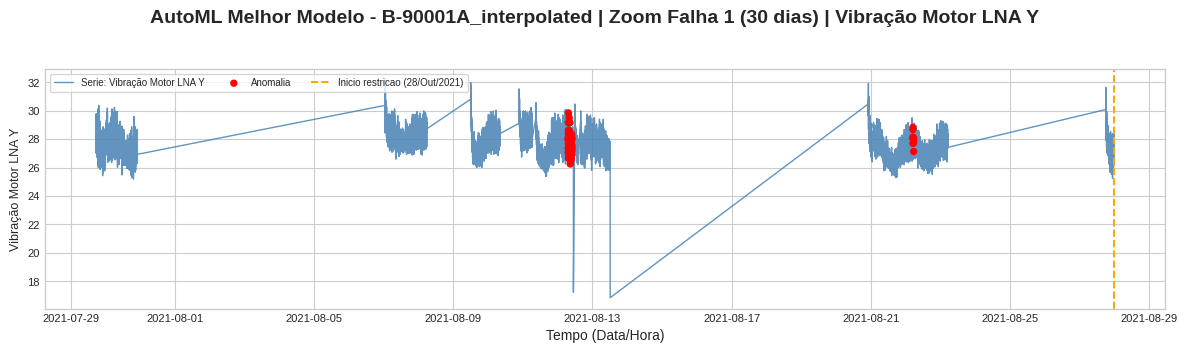

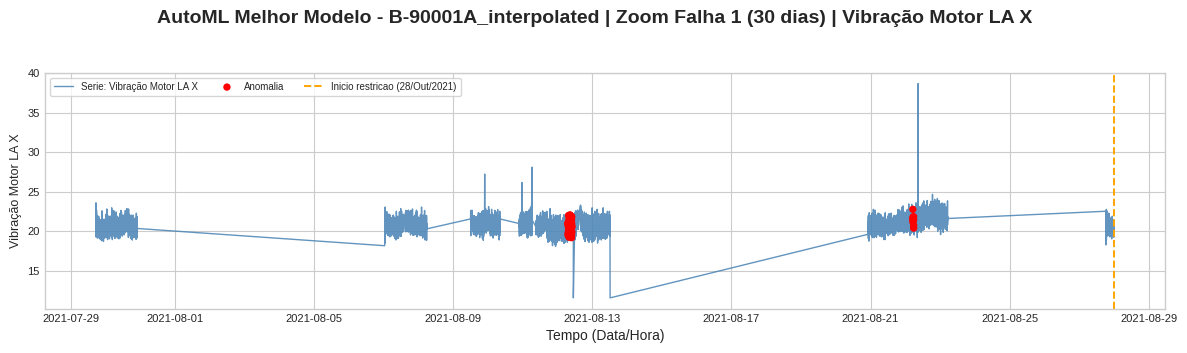

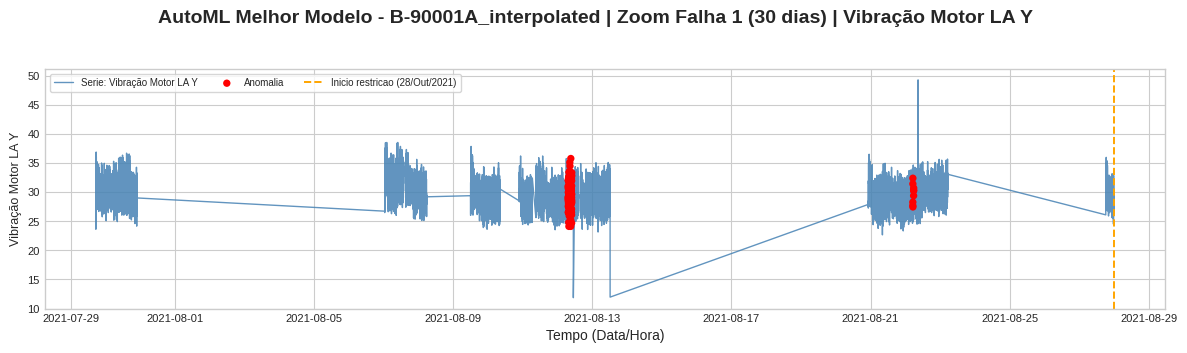

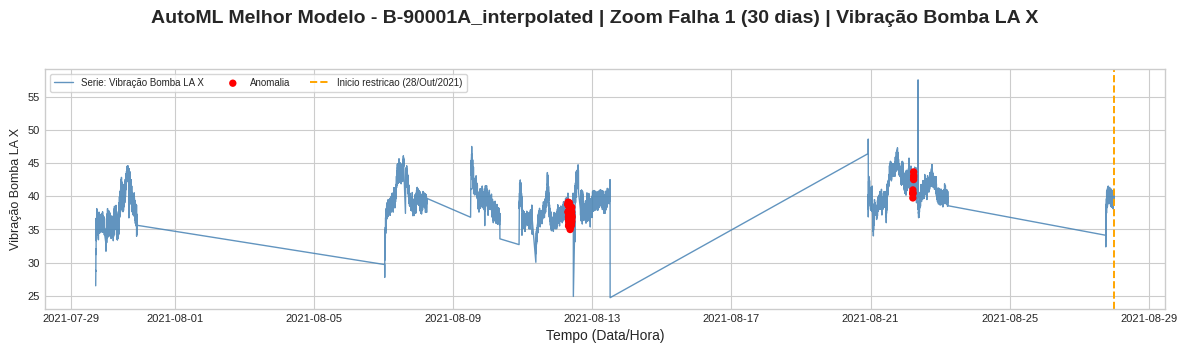

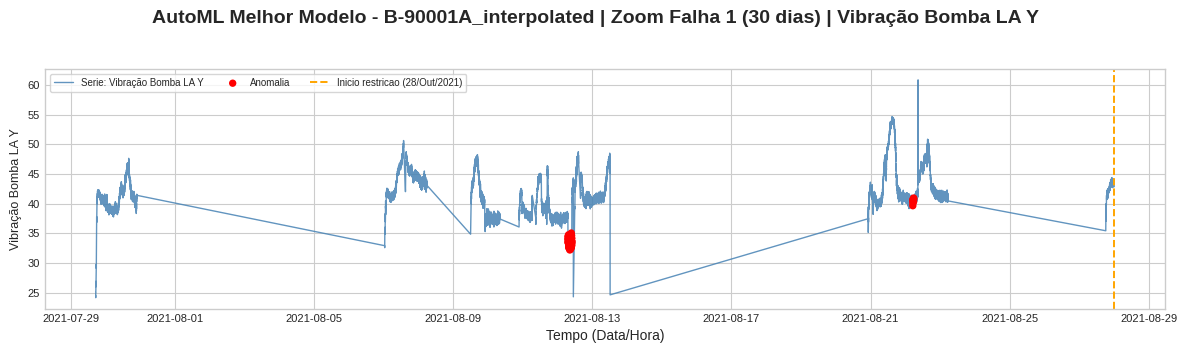

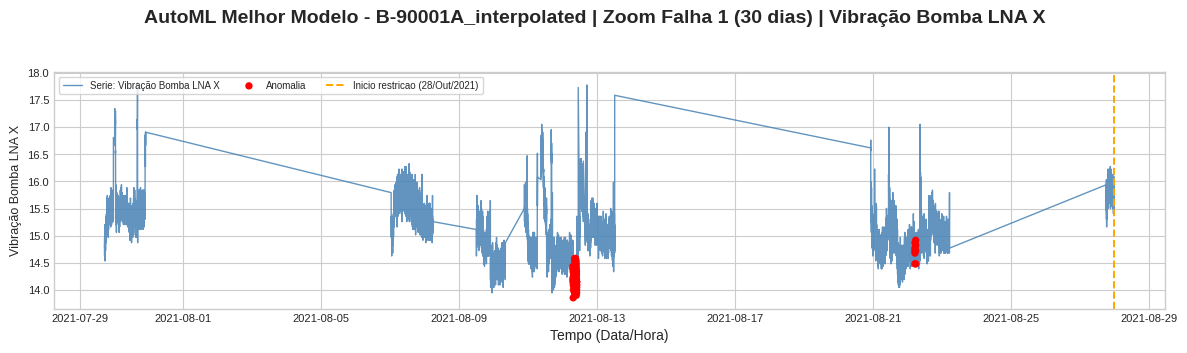

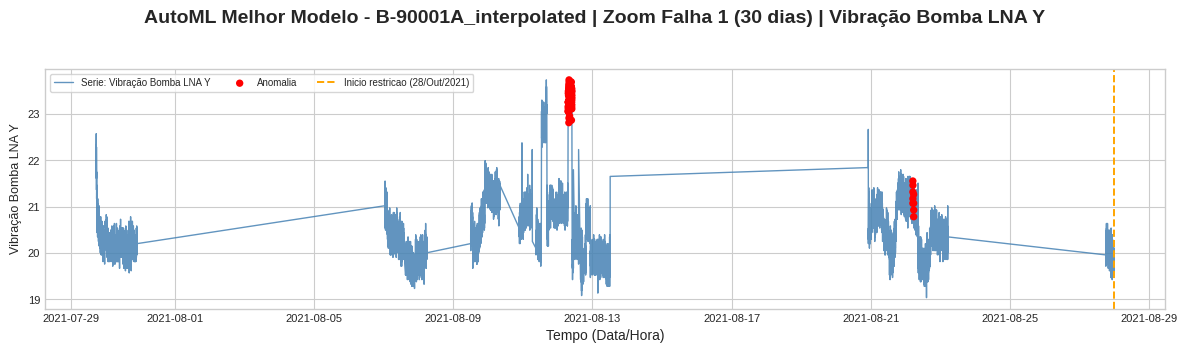

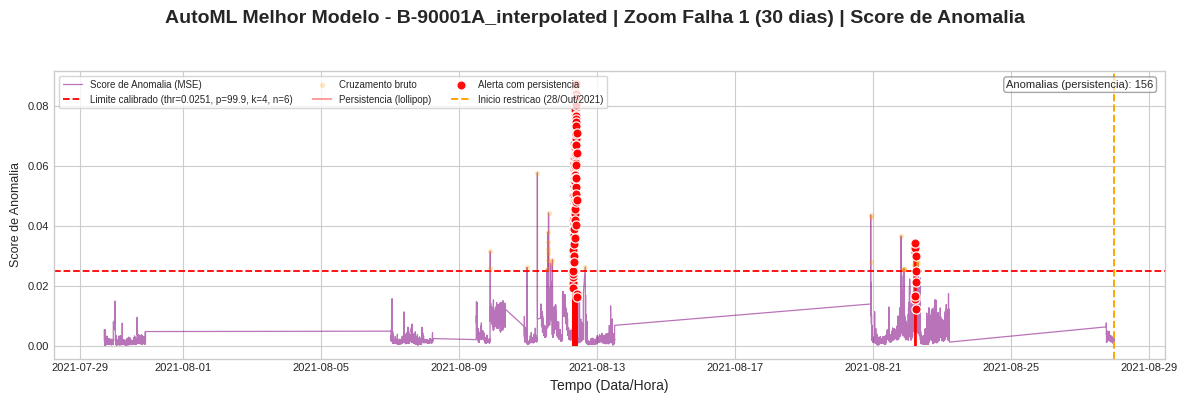


Resumo por janela:


,janela,inicio,fim,n_samples,n_anomalies,pct_anomalies,threshold,k,n
0,Periodo completo ate falha,2020-12-16 18:04:00,2021-08-28,203626,166,0.08,0.025053,4,6
1,Zoom Falha 1 (30 dias),2021-07-29 00:00:00,2021-08-28,11584,156,1.35,0.025053,4,6


In [14]:
windows = [
    {
        'name': 'Periodo completo ate falha',
        'start': scores.index.min(),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'AutoML Melhor Modelo - {EQUIPMENT_ID} | Periodo completo',
        'out': PROJECT_ROOT / 'notebooks' / f'automl_best_full_{TASK_ID[:8]}.png',
    },
    {
        'name': 'Zoom Falha 1 (30 dias)',
        'start': EVENT_TS_F1 - pd.Timedelta(days=30),
        'end': EVENT_TS_F1,
        'event_date': EVENT_DATE_F1,
        'event_label': EVENT_LABEL_F1,
        'title': f'AutoML Melhor Modelo - {EQUIPMENT_ID} | Zoom Falha 1 (30 dias)',
        'out': PROJECT_ROOT / 'notebooks' / f'automl_best_zoom30_{TASK_ID[:8]}.png',
    },
]

summary_rows = []

for w in windows:
    df_window, scores_window = slice_window(df_base, scores, w['start'], w['end'])
    threshold_flags = scores_window['reconstruction_error'] > selected_threshold
    anomaly_flags = persistence_filter(threshold_flags, k=selected_k, n=selected_n)
    n_anom = int(anomaly_flags.sum())

    plot_anomaly_panels(
        df_window=df_window,
        scores_window=scores_window,
        threshold_flags=threshold_flags,
        anomaly_flags=anomaly_flags,
        threshold=selected_threshold,
        threshold_label=threshold_label,
        n_anomalies=n_anom,
        event_date=pd.Timestamp(w['event_date']),
        event_label=w['event_label'],
        title=w['title'],
        output_path=w['out'],
        dpi=OUTPUT_DPI,
        plot_mode=PLOT_MODE,
        save_plots=SAVE_PLOTS,
        anomaly_highlight_style=ANOMALY_HIGHLIGHT_STYLE,
    )

    n_samples = len(scores_window)
    summary_rows.append({
        'janela': w['name'],
        'inicio': pd.Timestamp(w['start']),
        'fim': pd.Timestamp(w['end']),
        'n_samples': n_samples,
        'n_anomalies': n_anom,
        'pct_anomalies': round(100.0 * n_anom / n_samples, 2) if n_samples else 0.0,
        'threshold': selected_threshold,
        'k': selected_k,
        'n': selected_n,
    })

print('\nResumo por janela:')
display(pd.DataFrame(summary_rows))